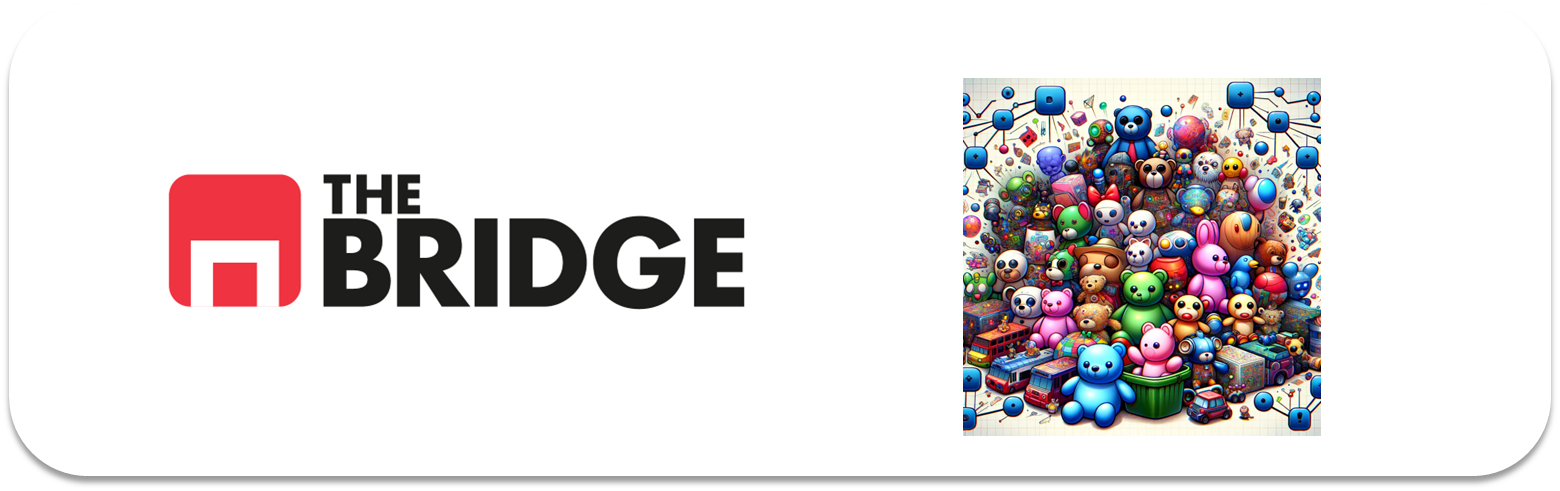

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [29]:
df = pd.read_csv('./data/empowering_drinks.csv', sep='|')
print(df.dtypes)
df.head()

Azúcares                 float64
Vitamínas del grupo B    float64
Cafeína                  float64
Ácido Cítrico            float64
Taurina                  float64
dtype: object


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [31]:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


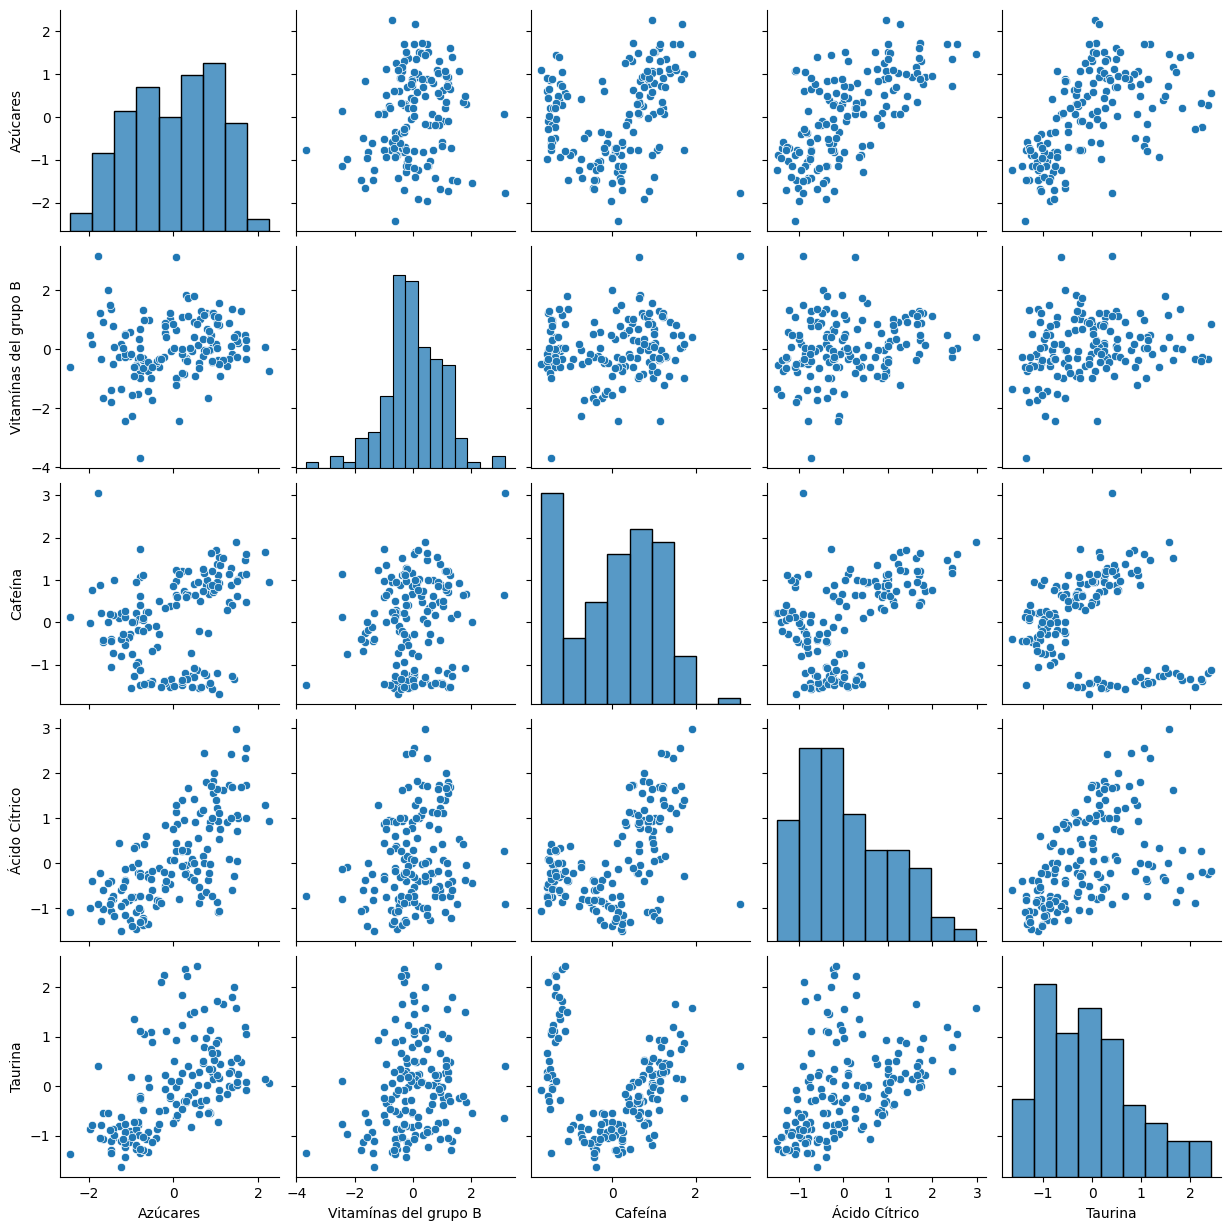

In [32]:
# Pairplot para ver si hay agrupaciones visuales entre features
sns.pairplot(df)
plt.show()

In [33]:
print(df.dtypes)
print(df.head())

Azúcares                 float64
Vitamínas del grupo B    float64
Cafeína                  float64
Ácido Cítrico            float64
Taurina                  float64
dtype: object
   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina
0  1.518613               0.232053  1.034819       1.013009  0.251717
1  0.246290              -0.827996  0.733629       0.965242 -0.293321
2  0.196879               1.109334  1.215533       1.395148  0.269020
3  1.691550               0.487926  1.466525       2.334574  1.186068
4  0.295700               1.840403  0.663351      -0.037874 -0.319276


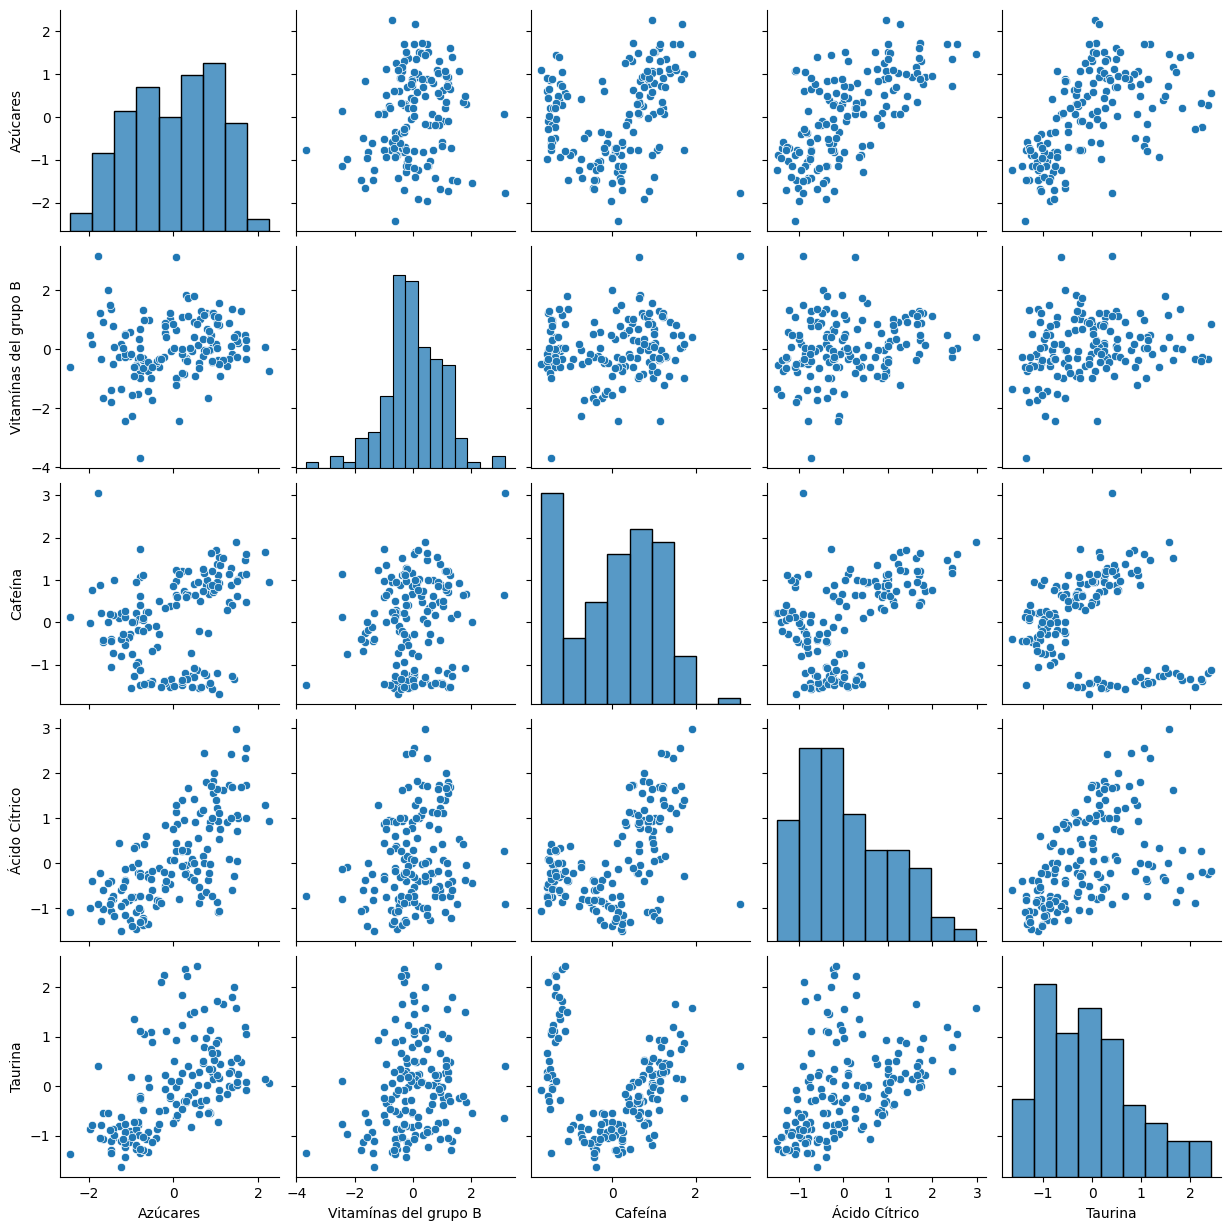

In [34]:
sns.pairplot(df)
plt.show()

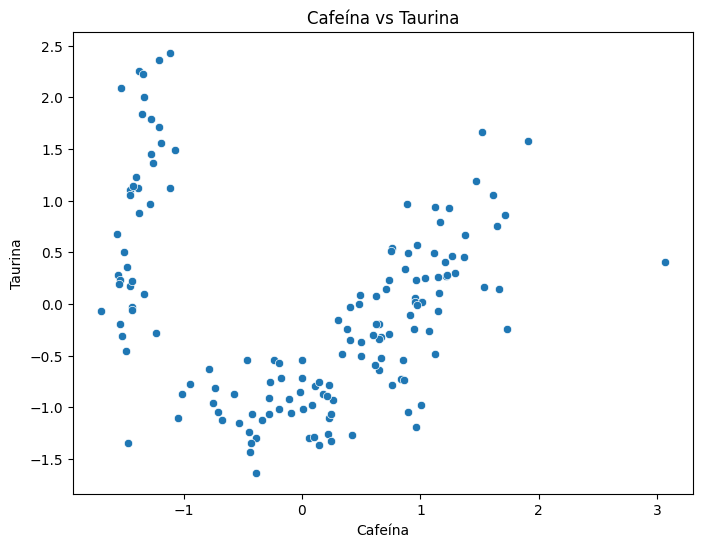

In [35]:
# Cafeína vs Taurina — el par he tenido que cotillear algo del profesor
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Cafeína", y="Taurina")
plt.title("Cafeína vs Taurina")
plt.show()

In [36]:
# Escalamos todo el dataset antes de aplicar los modelos
scaler = StandardScaler()
train_set = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
train_set.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.465925,0.196207,0.957824,0.927289,0.317612
1,0.221992,-0.871612,0.667526,0.879813,-0.267608
2,0.173684,1.079919,1.132002,1.307094,0.336190
3,1.635003,0.453956,1.373917,2.240782,1.320844
4,0.270301,1.816346,0.599790,-0.117176,-0.295475


In [37]:
# Iteramos sobre eps y min_samples para ver el % de anomalías
experiments = {}
for min_samples in [3, 5, 10]:
    print(f"Min_samples = {min_samples}")
    outlier_percent = []
    for eps in np.linspace(0.001, 6, 100):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(train_set)
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        outlier_percent.append(perc_outliers)
    experiments[min_samples] = outlier_percent.copy()

Min_samples = 3
Min_samples = 5
Min_samples = 10


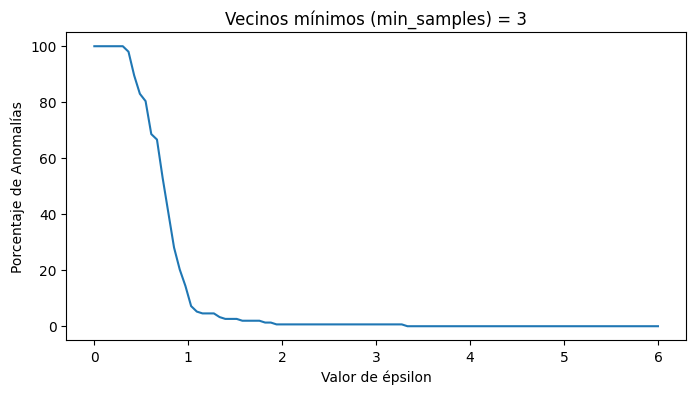

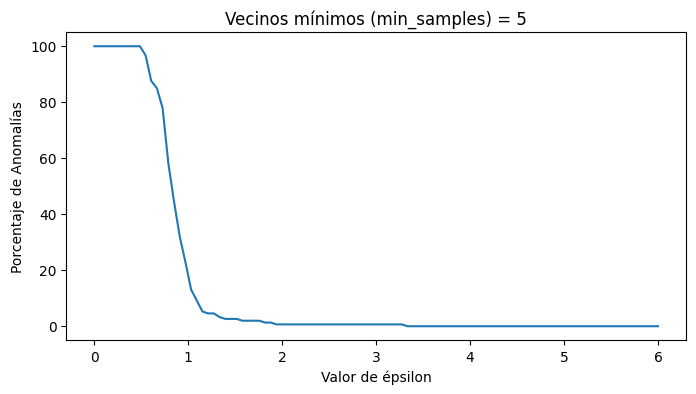

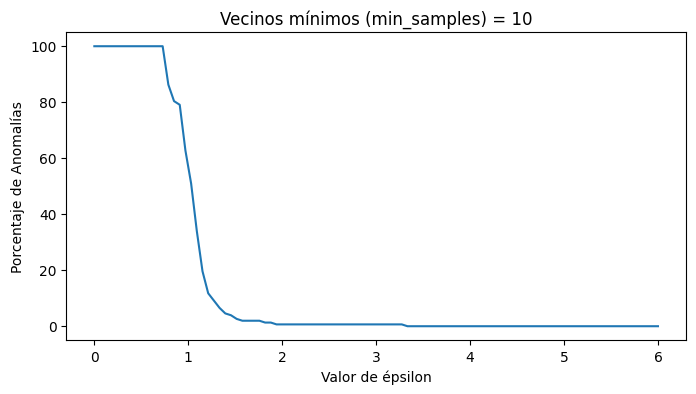

In [38]:
# % de anomalías vs eps para cada min_samples
for min_samples in [3, 5, 10]:
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments[min_samples])
    plt.ylabel("Porcentaje de Anomalías")
    plt.xlabel("Valor de épsilon")
    plt.title(f"Vecinos mínimos (min_samples) = {min_samples}")
    plt.show()

In [39]:
# Miramos en el rango 1.2-2 cuántos clusters salen para cada min_samples
for min_samples in [3, 5, 10]:
    print(f"Para num_samples = {min_samples}:")
    for indice, valor in enumerate(np.linspace(0.001, 6, 100)):
        if 1.2 <= valor <= 2:
            print(f"  eps={valor:.3f} -> {experiments[min_samples][indice]:.1f}% anomalías")

Para num_samples = 3:
  eps=1.213 -> 4.6% anomalías
  eps=1.274 -> 4.6% anomalías
  eps=1.334 -> 3.3% anomalías
  eps=1.395 -> 2.6% anomalías
  eps=1.455 -> 2.6% anomalías
  eps=1.516 -> 2.6% anomalías
  eps=1.576 -> 2.0% anomalías
  eps=1.637 -> 2.0% anomalías
  eps=1.698 -> 2.0% anomalías
  eps=1.758 -> 2.0% anomalías
  eps=1.819 -> 1.3% anomalías
  eps=1.879 -> 1.3% anomalías
  eps=1.940 -> 0.7% anomalías
Para num_samples = 5:
  eps=1.213 -> 4.6% anomalías
  eps=1.274 -> 4.6% anomalías
  eps=1.334 -> 3.3% anomalías
  eps=1.395 -> 2.6% anomalías
  eps=1.455 -> 2.6% anomalías
  eps=1.516 -> 2.6% anomalías
  eps=1.576 -> 2.0% anomalías
  eps=1.637 -> 2.0% anomalías
  eps=1.698 -> 2.0% anomalías
  eps=1.758 -> 2.0% anomalías
  eps=1.819 -> 1.3% anomalías
  eps=1.879 -> 1.3% anomalías
  eps=1.940 -> 0.7% anomalías
Para num_samples = 10:
  eps=1.213 -> 11.8% anomalías
  eps=1.274 -> 9.2% anomalías
  eps=1.334 -> 6.5% anomalías
  eps=1.395 -> 4.6% anomalías
  eps=1.455 -> 3.9% anomalías
  

In [40]:
# Cuántos clusters salen para eps=1.3 con cada min_samples
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=1.3, min_samples=min_samples)
    dbscan.fit(train_set)
    n_clusters = pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()
    print(f"min_samples={min_samples}: {n_clusters} clusters, {np.sum(dbscan.labels_ == -1)} anomalías")

min_samples=3: 1 clusters, 5 anomalías
min_samples=5: 1 clusters, 5 anomalías
min_samples=10: 1 clusters, 12 anomalías


In [41]:
# Sólo había 1 cluster, bajamos más
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=1.0, min_samples=min_samples)
    dbscan.fit(train_set)
    n_clusters = pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()
    print(f"min_samples={min_samples}: {n_clusters} clusters, {np.sum(dbscan.labels_ == -1)} anomalías")

min_samples=3: 4 clusters, 19 anomalías
min_samples=5: 3 clusters, 33 anomalías
min_samples=10: 2 clusters, 88 anomalías


In [42]:
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=1.1, min_samples=min_samples)
    dbscan.fit(train_set)
    n_clusters = pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()
    print(f"min_samples={min_samples}: {n_clusters} clusters, {np.sum(dbscan.labels_ == -1)} anomalías")

min_samples=3: 2 clusters, 8 anomalías
min_samples=5: 2 clusters, 14 anomalías
min_samples=10: 3 clusters, 51 anomalías


In [43]:
# Modelo DBSCAN definitivo — 3 clusters, dentro del rango que sugieren los químicos
dbscan_final = DBSCAN(eps=1.0, min_samples=5)
dbscan_final.fit(train_set)

train_set_dbscan = train_set.copy()
train_set_dbscan["Cluster"] = dbscan_final.labels_

print(pd.Series(dbscan_final.labels_).value_counts())

 0    49
 1    41
-1    33
 2    30
Name: count, dtype: int64


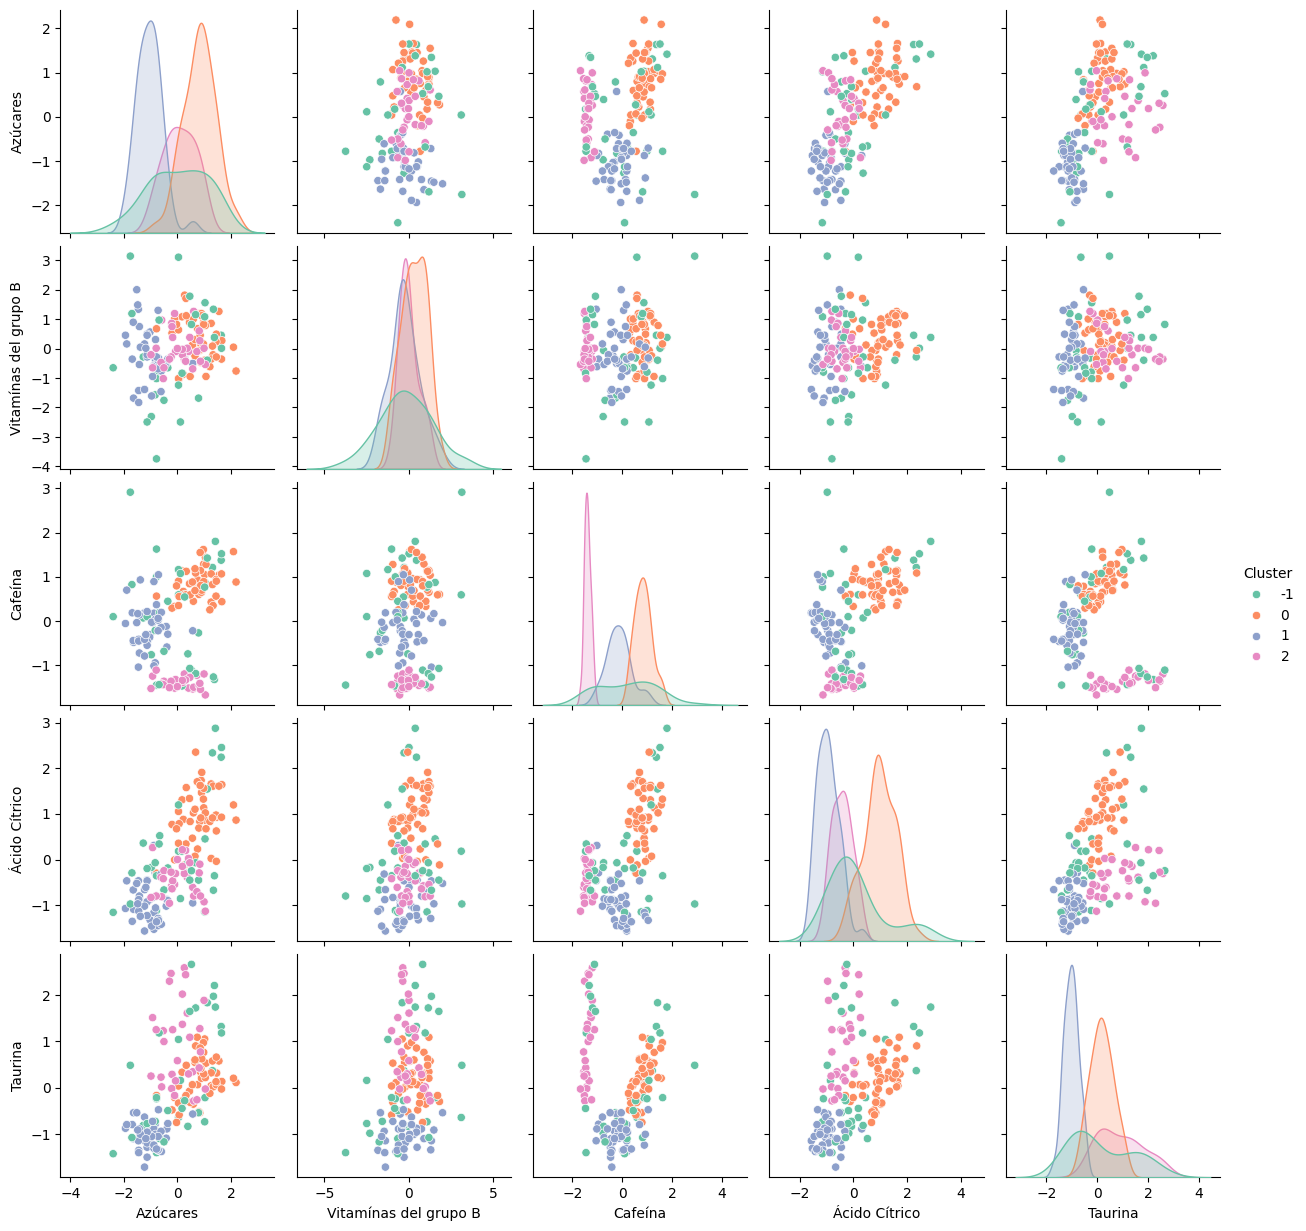

In [44]:
# Pairplot con los clusters asignados
sns.pairplot(train_set_dbscan, hue="Cluster", palette="Set2")
plt.show()

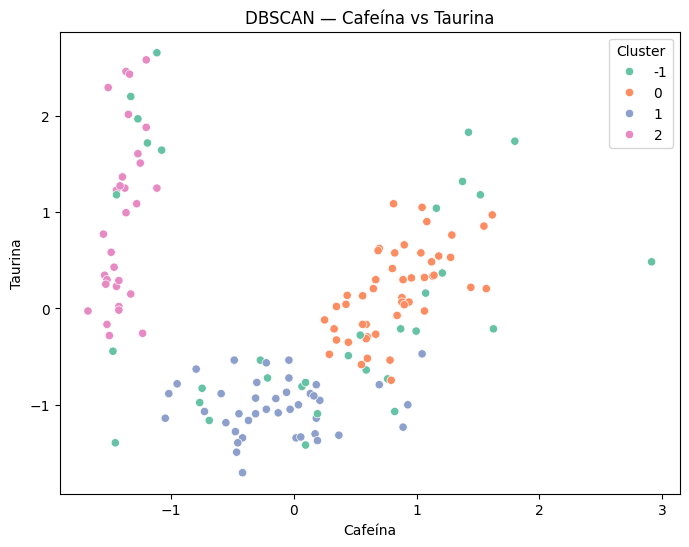

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_set_dbscan, x="Cafeína", y="Taurina", hue="Cluster", palette="Set2")
plt.title("DBSCAN — Cafeína vs Taurina")
plt.show()

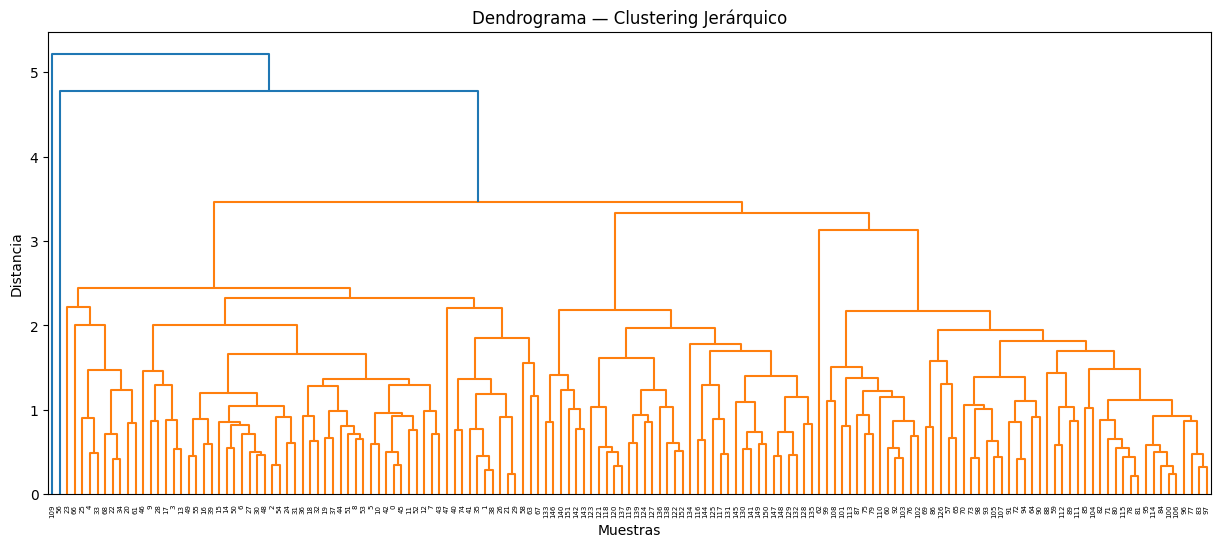

In [46]:
# Clustering jerárquico — relaciones entre segmentos
link_method = linkage(train_set, method='average')

plt.figure(figsize=(15, 6))
dendrogram(link_method)
plt.title("Dendrograma — Clustering Jerárquico")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()

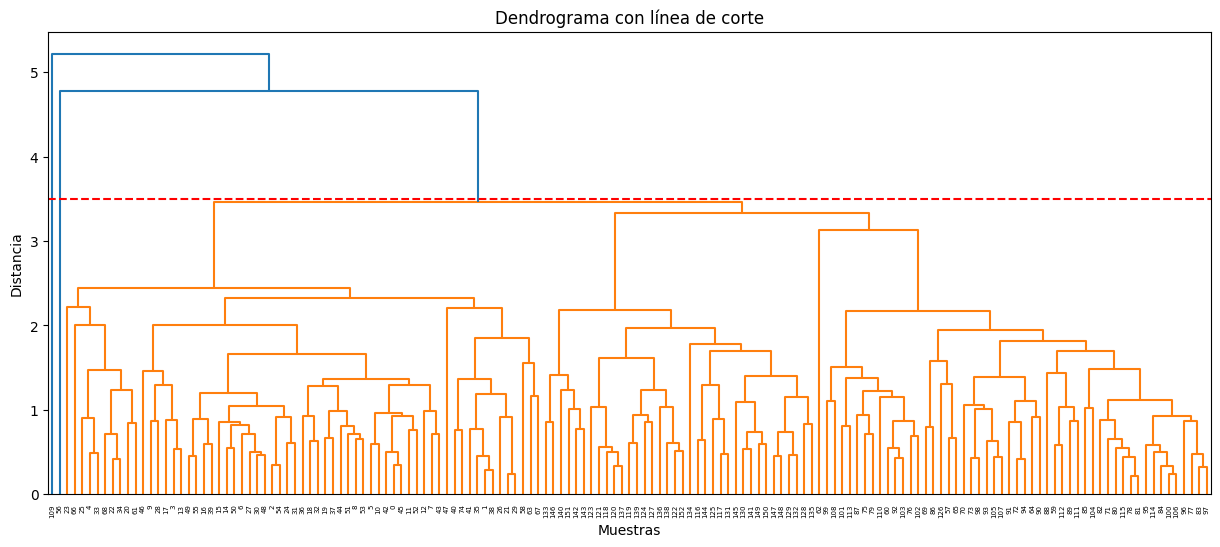

In [47]:
plt.figure(figsize=(15, 6))
dendrogram(link_method)
plt.axhline(y=3.5, color='r', linestyle='--')
plt.title("Dendrograma con línea de corte")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()

In [48]:
# Clustering jerárquico con 3 clusters
hier_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='average')
hier_model.fit(train_set)

train_set_hier = train_set.copy()
train_set_hier["Cluster"] = hier_model.labels_

print(train_set_hier["Cluster"].value_counts())

Cluster
0    151
2      1
1      1
Name: count, dtype: int64


In [49]:
features_short = ["Cafeína", "Taurina"]

hier_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='average')
hier_model.fit(train_set[features_short])

train_set_hier = train_set.copy()
train_set_hier["Cluster"] = hier_model.labels_

print(train_set_hier["Cluster"].value_counts())

Cluster
0    115
2     37
1      1
Name: count, dtype: int64


In [50]:
hier_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hier_model.fit(train_set[features_short])

train_set_hier = train_set.copy()
train_set_hier["Cluster"] = hier_model.labels_

print(train_set_hier["Cluster"].value_counts())

Cluster
1    73
2    43
0    37
Name: count, dtype: int64


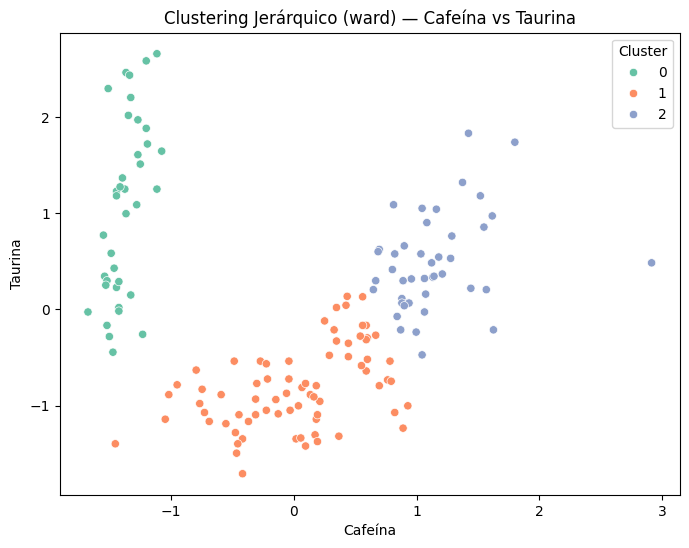

In [51]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_set_hier, x="Cafeína", y="Taurina", hue="Cluster", palette="Set2")
plt.title("Clustering Jerárquico (ward) — Cafeína vs Taurina")
plt.show()

## Parte I — Discusión

Se han construido dos modelos de clustering: DBSCAN y Clustering Jerárquico.

Ambos encuentran 3 segmentos coherentes con la nota orientativa de los químicos (3-5 clusters), 
principalmente diferenciados por las features Cafeína y Taurina, que son las más discriminantes.

La comparación entre modelos es especulativa porque en clustering no supervisado no tenemos 
un target real contra el que evaluar — no sabemos cuál es la "respuesta correcta". 
Ambos modelos coinciden en la estructura general del espacio Cafeína-Taurina, 
lo que refuerza que esa agrupación tiene sentido.

DBSCAN identifica además 33 anomalías (mezclas que no encajan en ningún grupo), 
información útil para los químicos ya que son experimentos atípicos.
El jerárquico en cambio agrupa todo sin descartar nada, y además permite ver 
qué segmentos son más similares entre sí a través del dendrograma.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [52]:
# Cargamos los nuevos experimentos
df_new = pd.read_csv('./data/new_experiments.csv', sep='|')
print(df_new.shape)
df_new.head()

(6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [53]:
# Escalamos los nuevos experimentos con el mismo scaler que usamos en el train
new_experiments_scaled = pd.DataFrame(scaler.transform(df_new), columns=df_new.columns)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(train_set_hier[features_short], train_set_hier["Cluster"])

new_experiments_scaled["Cluster"] = knn.predict(new_experiments_scaled[features_short])
print(new_experiments_scaled["Cluster"].value_counts())

Cluster
1    3
0    2
2    1
Name: count, dtype: int64


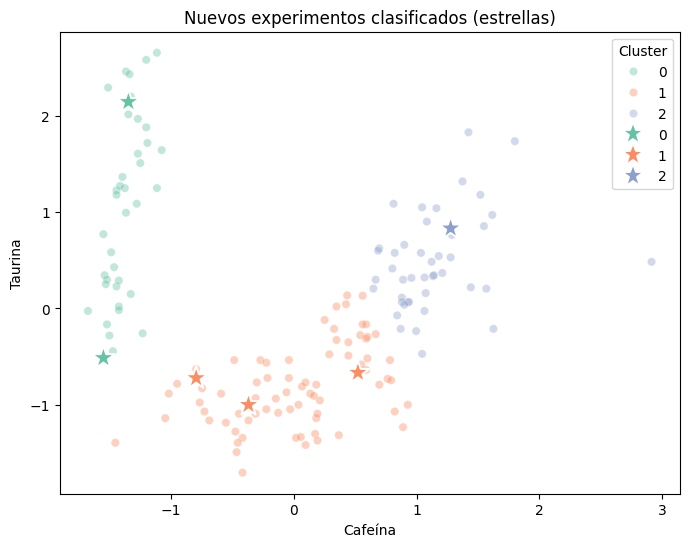

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_set_hier, x="Cafeína", y="Taurina", hue="Cluster", palette="Set2", alpha=0.4)
sns.scatterplot(data=new_experiments_scaled, x="Cafeína", y="Taurina", hue="Cluster", palette="Set2", marker="*", s=300)
plt.title("Nuevos experimentos clasificados (estrellas)")
plt.show()

## Parte II — Conclusión

Los 6 nuevos experimentos han sido clasificados usando KNN entrenado con las etiquetas 
del clustering jerárquico. Al no tener predict nativo en DBSCAN, KNN es la solución 
más sencilla para generalizar a nuevos datos.

Los nuevos experimentos se distribuyen coherentemente dentro de los clusters existentes,
lo que sugiere que el modelo generaliza bien a mezclas no vistas.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.